# Overview
This program simulates the first 15 minutes of League of Legends in the persepective of the jungler within 10 turn and returns the probability of winning given the final state of values. The simulation was created to match the distributions of the actual data set. An AI agent is then trained on that simulation to play as the enemy resulting in the distributions being shifted to the left, overall decreasing the chances of winning.

# Model

In [1]:
# train_win_model.py

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import joblib


def main():
    data_path = "LoL_15_Diamond.csv"   # 15-min Kaggle dataset
    df = pd.read_csv(data_path)

    feature_cols = [
        "blue_Total_Gold",
        "blue_Kills",
        "blue_Dragons",
        "blue_Void_Grubs",
        "blue_Heralds",
        "blue_Towers_Destroyed",
        "blue_Avg_Level",
    ]

    X = df[feature_cols]
    y = df["blue_Win"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = LogisticRegression(max_iter=5000)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("AUC:", roc_auc_score(y_test, y_proba))
    print("\nClassification report:\n", classification_report(y_test, y_pred))

    joblib.dump(model, "win_probability_model.joblib")
    print("\nSaved model to win_probability_model.joblib")


if __name__ == "__main__":
    main()


Accuracy: 0.7262375087148502
AUC: 0.8002315652941111

Classification report:
               precision    recall  f1-score   support

         0.0       0.72      0.74      0.73      2147
         1.0       0.74      0.71      0.72      2156

    accuracy                           0.73      4303
   macro avg       0.73      0.73      0.73      4303
weighted avg       0.73      0.73      0.73      4303


Saved model to win_probability_model.joblib


# Value Initialization

In [8]:
%%file lol_engine.py

from __future__ import annotations
from dataclasses import dataclass, field
from enum import Enum, auto
from typing import Dict, List, Optional, Any, Sequence
import random
import pandas as pd


# ============================================================
# 1. BASIC ENUMS & DATA STRUCTURES
# ============================================================

class Phase(Enum):
    """High-level scripted phases for our 10 'turns'."""
    T1_INVASION = auto()
    T2_POST_CLEAR = auto()
    T3_PRE_DRAGON = auto()
    T4_DRAGON = auto()
    T5_GRUBS = auto()
    T6_MIDGAME = auto()
    T7_DUAL_OBJECTIVES = auto()
    T8_FOLLOWUP = auto()
    T9_HERALD = auto()
    T10_FINAL = auto()
    DONE = auto()


class Action(Enum):
    """Actions the PLAYER jungler can choose."""
    FARM = auto()
    GANK_TOP = auto()
    GANK_MID = auto()
    GANK_BOT = auto()
    INVADE = auto()               # only used on T1
    CONTEST_OBJECTIVE = auto()
    GIVE_OBJECTIVE = auto()
    STEAL_ATTEMPT = auto()
    DO_NOTHING = auto()
    # special for dual objectives: which one you play for
    GO_DRAGON = auto()
    GO_GRUBS = auto()


@dataclass
class EventResult:
    """What happened during a step."""
    description: str
    payload: Dict[str, Any] = field(default_factory=dict)


@dataclass
class ChampionLaneProfile:
    """Optional stats for a lane's champion, if you want to use them."""
    damage: int
    toughness: int
    control: int
    mobility: int
    utility: int


@dataclass
class GameState:
    # --- 15-min style ML features ---
    blue_Total_Gold: float = 2500.0
    blue_Kills: int = 0
    blue_Dragons: int = 0
    blue_Void_Grubs: int = 0
    blue_Heralds: int = 0
    blue_Towers_Destroyed: int = 0
    blue_Avg_Level: float = 1.0

    # --- internal latent state ---
    map_pressure: float = 0.0         # roughly [-3, 3]
    jungle_tempo: float = 0.0         # roughly [-3, 3]
    lane_adv_score: Dict[str, int] = field(default_factory=dict)
    lane_adv_hidden: Dict[str, float] = field(default_factory=dict)


    # champion profiles when you pick teams
    blue_profiles: Dict[str, ChampionLaneProfile] = field(default_factory=dict)
    red_profiles: Dict[str, ChampionLaneProfile] = field(default_factory=dict)

    # jungler vs jungler matchup advantage (-3..3)
    jungle_matchup_adv: int = 0

    # to track ganks for FF logic later
    lane_ganks_success: Dict[str, int] = field(
        default_factory=lambda: {"top": 0, "mid": 0, "bot": 0}
    )
    lane_ganks_fail: Dict[str, int] = field(
        default_factory=lambda: {"top": 0, "mid": 0, "bot": 0}
    )

    # step + phase
    step_index: int = 1
    phase: Phase = Phase.T1_INVASION

    # flags across steps
    last_action: Optional[Action] = None
    last_gank_failed_pre_objective: bool = False
    last_objective: Optional[str] = None       # "dragon" / "grubs" / "dual" / "herald"
    grubs_taken_anytime: bool = False          # for herald spawning
    grubs_cleared_anytime: bool = False
    dragon_taken_anytime: bool = False
    dual_remaining: Optional[str] = None       # "dragon" or "grubs" after T7, if any

    # final ML prob
    final_p_win: Optional[float] = None

    def to_ml_vector(self) -> List[float]:
        """Order must match your training script."""
        return [
            self.blue_Total_Gold,
            self.blue_Kills,
            self.blue_Dragons,
            self.blue_Void_Grubs,
            self.blue_Heralds,
            self.blue_Towers_Destroyed,
            self.blue_Avg_Level,
        ]

    def to_rl_vector(self):
        """Vector for RL agent including non-ML features."""
        return self.to_ml_vector() + [
            self.map_pressure,
            self.jungle_tempo,
            self.lane_adv_score["top"],
            self.lane_adv_score["mid"],
            self.lane_adv_score["bot"],
            self.phase.value,
        ]


# ============================================================
# 2. WIN PROBABILITY WRAPPER
# ============================================================

class WinProbabilityModel:
    """Wraps a scikit-learn classifier that has predict_proba."""

    def __init__(self, sklearn_model):
        self.model = sklearn_model
        self.columns = [
            "blue_Total_Gold",
            "blue_Kills",
            "blue_Dragons",
            "blue_Void_Grubs",
            "blue_Heralds",
            "blue_Towers_Destroyed",
            "blue_Avg_Level",
        ]

    def predict_win_prob(self, state: GameState) -> float:
        x = pd.DataFrame([state.to_ml_vector()], columns=self.columns)
        proba = self.model.predict_proba(x)[0][1]
        return float(proba)


Overwriting lol_engine.py


# Event Logic

In [9]:
%%file -a lol_engine.py

# ============================================================
# 3. EVENT RESOLVER 
# ============================================================

class EventResolver:
    def __init__(self, state: GameState):
        self.s = state

    # ---------- tiny helpers ----------

    @staticmethod
    def _clamp(v: float, lo: float, hi: float) -> float:
        return max(lo, min(hi, v))

    def _sync_lane_score(self, lane: str):
        """Sync integer lane_adv_score[-3..3] from hidden float."""
        h = self._clamp(self.s.lane_adv_hidden[lane], -3.0, 3.0)
        self.s.lane_adv_hidden[lane] = h
        self.s.lane_adv_score[lane] = int(round(h))

    # ---------- XP helper (fixed clamp) ----------

    def _gain_xp(self, amount: float):
        """
        XP is always non-negative, we just give less XP for bad events.
        clamp lower bound at 1.0 (starting level), upper ~14 for safety.
        """
        self.s.blue_Avg_Level = self._clamp(self.s.blue_Avg_Level + amount, 1.0, 14.0)

    # =======================================================
    # PASSIVE LANE TICKS
    # =======================================================

    def resolve_lane_tick(self) -> List[EventResult]:
        """
        Passive lane events every step: kills / deaths, and towers near the end.
        Frequencies tuned to be 'moderate' but more realistic.
        """
        results: List[EventResult] = []

        prob_table = {
            3:  (0.45, 0.05),
            2:  (0.32, 0.08),
            1:  (0.21, 0.10),
            0:  (0.12, 0.08),
            -1: (0.12, 0.18),
            -2: (0.09, 0.28),
            -3: (0.05, 0.35),
        }

        for lane in ["top", "mid", "bot"]:
            score = self.s.lane_adv_score[lane]
            kill_p, death_p = prob_table.get(score, (0.08, 0.08))
            r = random.random()
            if r < kill_p:
                self._apply_lane_kill(lane, results)
            elif r < kill_p + death_p:
                self._apply_lane_death(lane, results)

        # Tower logic only near end (Herald / Final)
        if self.s.phase in {Phase.T9_HERALD, Phase.T10_FINAL}:
            for lane in ["top", "mid", "bot"]:
                score = self.s.lane_adv_score[lane]
                if score == 3:
                    self._grant_lane_tower(lane, results, guaranteed=True)
                elif score == 2 and random.random() < 0.25:
                    self._grant_lane_tower(lane, results, guaranteed=False)
                elif score == -3:
                    self._lose_lane_tower(lane, results, guaranteed=True)
                elif score == -2 and random.random() < 0.25:
                    self._lose_lane_tower(lane, results, guaranteed=False)

        return results

    def _apply_lane_kill(self, lane: str, results: List[EventResult]):
        self.s.blue_Kills += 1
        self.s.blue_Total_Gold += 300   
        self.s.map_pressure += 0.15
        self.s.lane_adv_hidden[lane] += 0.45
        self._gain_xp(0.2)

        # BOT LANE: support always gets assist as well
        if lane == "bot":
            self.s.blue_Total_Gold += 150
            self._gain_xp(0.1)
            
        self._sync_lane_score(lane)
        results.append(EventResult(f"{lane.capitalize()} lane secured a kill."))

    def _apply_lane_death(self, lane: str, results: List[EventResult]):
        self.s.map_pressure -= 0.10
        self._gain_xp(0.1)
        self.s.lane_adv_hidden[lane] -= 0.35
        self._sync_lane_score(lane)
        results.append(EventResult(f"{lane.capitalize()} lane died."))

    def _grant_lane_tower(self, lane: str, results: List[EventResult], guaranteed: bool):
        self.s.blue_Towers_Destroyed += 1
        self.s.blue_Total_Gold += 1200
        self.s.map_pressure += 0.30
        self._gain_xp(0.20)
        tag = "guaranteed" if guaranteed else "chance"
        results.append(EventResult(f"{lane.capitalize()} lane destroyed an enemy tower."))

    def _lose_lane_tower(self, lane: str, results: List[EventResult], guaranteed: bool):
        # again: no gold loss, just pressure + XP (game goes on)
        self.s.map_pressure -= 0.25
        tag = "guaranteed" if guaranteed else "chance"
        results.append(EventResult(f"{lane.capitalize()} lane lost their tower."))

    # =======================================================
    # FARM
    # =======================================================

    def resolve_farm(self) -> List[EventResult]:
        """
        Farming should be a big part of gold + XP growth.
        """
        self.s.blue_Total_Gold += 700
        self.s.jungle_tempo += 0.25
        self.s.map_pressure += 0.05
        self._gain_xp(0.475)
        return [EventResult("You cleared your jungle camps and farmed safely.")]

    # =======================================================
    # GANKS
    # =======================================================

    def resolve_gank(self, lane: str) -> List[EventResult]:
        results: List[EventResult] = []
        p = self._compute_gank_success_probability(lane)
        r = random.random()
        if r < p:
            self._apply_gank_success(lane, results)
            self.s.last_gank_failed_pre_objective = False
        else:
            self._apply_gank_fail(lane, results)
            # this matters if it's the turn just before an objective
            self.s.last_gank_failed_pre_objective = True
        return results

    def _compute_gank_success_probability(self, lane: str) -> float:
        base = 0.50
        score = self.s.lane_adv_score[lane]      # -3..3
        lane_mod = 0.08 * (-score)               # worse lane → stronger incentive to gank
        jungle_mod = 0.10 * self.s.jungle_matchup_adv
        tempo_mod = 0.05 * self.s.jungle_tempo
        pressure_mod = 0.05 * self.s.map_pressure

        # simple lane stats bonus (if profiles available)
        prof = self.s.blue_profiles.get(lane)
        lane_mod2 = 0.0
        if prof is not None:
            lane_cc = prof.control / 3.0
            lane_damage = prof.damage / 3.0
            lane_mod2 = 0.05 * lane_cc + 0.05 * lane_damage

        p = base + lane_mod + jungle_mod + tempo_mod + pressure_mod + lane_mod2
        return self._clamp(p, 0.10, 0.90)

    def _apply_gank_success(self, lane: str, results: List[EventResult]):
        kills = 2 if lane == "bot" and random.random() < 0.5 else 1
        self.s.blue_Kills += kills
        self.s.blue_Total_Gold += random.randint(225, 325) # assuming farmed one side and ganked
        self.s.blue_Total_Gold += 300 * kills
        self.s.jungle_tempo += 0.60
        self.s.map_pressure += 0.35
        self._gain_xp(0.2 * kills)
        self._gain_xp(0.1 * kills)

        # BOT LANE: support always gets assist as well
        if lane == "bot":
            self.s.blue_Total_Gold += 150  # 150 shared gold for jungler and support assist
            self._gain_xp(0.175)           # Assist exp shared
            
        self.s.lane_adv_hidden[lane] += 0.65
        self._sync_lane_score(lane)
        self.s.lane_ganks_success[lane] += 1
        results.append(EventResult(f"Gank on {lane} lane SUCCEEDED ({kills} kill(s))."))

    def _apply_gank_fail(self, lane: str, results: List[EventResult]):
        self.s.jungle_tempo -= 0.40
        self.s.map_pressure -= 0.25
        self._gain_xp(0.05)
        self.s.blue_Total_Gold += random.randint(225, 325) # assuming farmed one side and ganked
        self.s.lane_adv_hidden[lane] -= 0.40
        self._sync_lane_score(lane)
        self.s.lane_ganks_fail[lane] += 1

        died = False
        if random.random() < 0.30:
            died = True
            self._gain_xp(0.05)
        msg = f"Gank on {lane} lane FAILED."
        if died:
            msg += " You died trying to escape."
        results.append(EventResult(msg))

    # =======================================================
    # INVADES (only really used on T1 for now)
    # =======================================================

    def resolve_invade(self, enemy_invades_as_well: bool = False) -> List[EventResult]:
        results: List[EventResult] = []
        if enemy_invades_as_well:
            # mirrored invade → camps traded
            self.s.blue_Total_Gold += 700
            self.s.jungle_tempo += 0.20
            self._gain_xp(0.20)
            results.append(EventResult("Both junglers invaded opposite sides. Camps traded."))
            return results

        p = self._compute_invade_success()
        r = random.random()
        if r < p:
            self._apply_invade_success(results)
        else:
            self._apply_invade_fail(results)
        return results

    def _compute_invade_success(self) -> float:
        base = 0.50
        jungle_mod = 0.10 * self.s.jungle_matchup_adv
        tempo_mod = 0.10 * self.s.jungle_tempo
        vision_mod = 0.05 * self.s.map_pressure
        p = base + jungle_mod + tempo_mod + vision_mod
        return self._clamp(p, 0.10, 0.90)

    def _apply_invade_success(self, results: List[EventResult]):
        self.s.blue_Total_Gold += 1000
        self.s.jungle_tempo += 0.70
        self.s.map_pressure += 0.35
        self._gain_xp(0.30)
        results.append(EventResult("Your invade SUCCEEDED."))

    def _apply_invade_fail(self, results: List[EventResult]):
        self.s.jungle_tempo -= 0.50
        self.s.map_pressure -= 0.30
        died = False
        if random.random() < 0.40:
            died = True
            self._gain_xp(0.10)
        msg = "Your invade FAILED."
        if died:
            msg += " You were killed in the enemy jungle."
        results.append(EventResult(msg))

    # =======================================================
    # OBJECTIVE FIGHTS: DRAGON / GRUBS / HERALD
    # =======================================================

    def _fight_power(self, lanes: Sequence[str]) -> float:
        power = 1.0
        power += 0.4 * self.s.jungle_matchup_adv
        if lanes:
            lane_sum = sum(self.s.lane_adv_score[l] for l in lanes)
            power += 0.3 * lane_sum / len(lanes)
        power += 0.2 * self.s.jungle_tempo
        power += 0.2 * self.s.map_pressure
        return max(0.1, power)

    def _contested_objective(self, lanes: Sequence[str]) -> bool:
        our = self._fight_power(lanes)
        enemy = max(0.1, 2.0 - (our - 1.0))  # rough symmetric-ish
        p_win = self._clamp(our / (our + enemy), 0.10, 0.90)
        return random.random() < p_win

    # -------- dragon --------

    def resolve_dragon_contest(self) -> List[EventResult]:
        results: List[EventResult] = []
        lanes = ["mid", "bot"]
        if self._contested_objective(lanes):
            self._apply_dragon_win(results, contested=True)
        else:
            self._apply_dragon_lose(results, contested=True)
        return results

    def _apply_dragon_win(self, results: List[EventResult], contested: bool):
        self.s.blue_Dragons += 1
        self.s.blue_Total_Gold += 975
        self.s.jungle_tempo += 0.40
        self.s.map_pressure += 0.40
        self._gain_xp(0.2)
        self.s.dragon_taken_anytime = True
        
        if contested:
            extra_kills = random.randint(1, 3)
            self.s.blue_Kills += extra_kills
            self.s.blue_Total_Gold += 300 * extra_kills
            self._gain_xp(0.15 * extra_kills)
            results.append(EventResult(f"You won the Dragon fight and secured {extra_kills} kill(s)."))
        else:
            results.append(EventResult(f"You secured Dragon for free."))

    def _apply_dragon_lose(self, results: List[EventResult], contested: bool):
        self.s.jungle_tempo -= 0.20
        self.s.map_pressure -= 0.25
        
        if contested:
            self.s.blue_Kills += 1
            self.s.blue_Total_Gold += 300
            self._gain_xp(0.1)
            results.append(EventResult("You lost the Dragon fight but secured 1 kill."))
        else:
            results.append(EventResult(f"Enemy took dragon uncontested."))

    # -------- grubs --------

    def resolve_grubs_contest(self) -> List[EventResult]:
        results: List[EventResult] = []
        lanes = ["top", "mid"]
        if self._contested_objective(lanes):
            self._apply_grubs_win(results, contested=True)
        else:
            self._apply_grubs_lose(results, contested=True)
        return results

    def _apply_grubs_win(self, results: List[EventResult], contested: bool):
        self.s.blue_Void_Grubs += 3
        self.s.blue_Total_Gold += 150
        self.s.jungle_tempo += 0.30
        self.s.map_pressure += 0.35
        self._gain_xp(0.2)
        self.s.grubs_taken_anytime = True
        self.s.grubs_cleared_anytime = True

        if contested:
            extra_kills = random.randint(1, 2)
            self.s.blue_Kills += extra_kills
            self.s.blue_Total_Gold += 300 * extra_kills
            self._gain_xp(0.15 * extra_kills)
            results.append(EventResult(f"You won the Grubs fight and secured {extra_kills} kill(s)."))
        else:
            results.append(EventResult(f"You secured Grubs for free."))


    def _apply_grubs_lose(self, results: List[EventResult], contested: bool):
        self.s.jungle_tempo -= 0.20
        self.s.map_pressure -= 0.25
        self.s.grubs_cleared_anytime = True

        if contested:
            self.s.blue_Kills += 1
            self.s.blue_Total_Gold += 300
            self._gain_xp(0.1)
            results.append(EventResult("You lost the Grubs fight but secured 1 kill."))
        else:
            results.append(EventResult(f"Enemy took Grubs uncontested."))

    # -------- herald --------

    def resolve_herald_contest(self) -> List[EventResult]:
        results: List[EventResult] = []
        lanes = ["top", "mid"]
        if self._contested_objective(lanes):
            self._apply_herald_win(results, contested=True)
        else:
            self._apply_herald_lose(results, contested=True)
        return results

    def _apply_herald_win(self, results: List[EventResult], contested: bool):
        self.s.blue_Heralds += 1
        self.s.blue_Total_Gold += 300
        self.s.jungle_tempo += 0.25
        self.s.map_pressure += 0.30
        self._gain_xp(0.2)

        if contested:
            extra_kills = random.randint(1, 2)
            self.s.blue_Kills += extra_kills
            self.s.blue_Total_Gold += 300 * extra_kills
            self._gain_xp(0.15 * extra_kills)
            results.append(EventResult(f"You won the Herald fight and secured {extra_kills} kill(s)."))
        else:
            results.append(EventResult(f"You secured Grubs for free."))

    def _apply_herald_lose(self, results: List[EventResult], contested: bool):
        self.s.jungle_tempo -= 0.20
        self.s.map_pressure -= 0.25

        if contested:
            self.s.blue_Kills += 1
            self.s.blue_Total_Gold += 300
            self._gain_xp(0.1)
            results.append(EventResult("You lost the Herald fight but secured 1 kill."))
        else:
            results.append(EventResult(f"Enemy took Herald uncontested."))

    # =======================================================
    # STEAL ATTEMPTS
    # =======================================================

    def resolve_steal(self, objective: str) -> List[EventResult]:
        """
        Steal attempt vs 'dragon' | 'grubs' | 'dual' | 'herald'.
        """
        results: List[EventResult] = []

        base = 0.18
        tempo_mod = 0.04 * self.s.jungle_tempo
        pressure_mod = 0.04 * self.s.map_pressure
        jungle_mod = 0.04 * self.s.jungle_matchup_adv
        p_steal = self._clamp(base + tempo_mod + pressure_mod + jungle_mod, 0.05, 0.40)

        r = random.random()
        success = r < p_steal

        if success:
            if objective in {"dragon", "dual"}:
                self._apply_dragon_win(results, contested=True)
            if objective in {"grubs", "dual"}:
                self._apply_grubs_win(results, contested=True)
            if objective == "herald":
                self._apply_herald_win(results, contested=True)

            died = random.random() < 0.40
            if died:
                self._gain_xp(0.20)
                results.append(EventResult("You stole the objective but died escaping."))
            else:
                results.append(EventResult("You stole the objective and got out alive!"))
        else:
            self._gain_xp(0.20)
            if objective in {"dragon", "dual"}:
                self._apply_dragon_lose(results, contested=False)
            if objective in {"grubs", "dual"}:
                self._apply_grubs_lose(results, contested=False)
            if objective == "herald":
                self._apply_herald_lose(results, contested=False)
            results.append(EventResult("Steal attempt FAILED. You died in the pit."))

        return results


Appending to lol_engine.py


# Turns

In [10]:
%%file -a lol_engine.py

# ============================================================
# 4. SIMULATOR (STATE MACHINE, NO I/O)
# ============================================================

class Simulator:
    """
    Pure engine: no input()/print() here.
    CLI / GUI should:
      - call get_available_actions()
      - let the player choose an Action
      - call step(action) -> List[EventResult]
      - read state attributes to display numbers
    """

    def __init__(self, state: GameState):
        self.s = state
        self.resolver = EventResolver(self.s)

    # ------------ API for external UI ------------

    def get_available_actions(self) -> List[Action]:
        p = self.s.phase

        # special case: if last_gank_failed_pre_objective and we are at an objective phase,
        # only allow steal vs do nothing.
        if p in {Phase.T4_DRAGON, Phase.T5_GRUBS, Phase.T7_DUAL_OBJECTIVES, Phase.T9_HERALD} \
           and self.s.last_gank_failed_pre_objective:
            return [Action.STEAL_ATTEMPT, Action.DO_NOTHING]

        if p == Phase.T1_INVASION:
            return [Action.FARM, Action.INVADE]

        if p in {Phase.T2_POST_CLEAR, Phase.T3_PRE_DRAGON, Phase.T6_MIDGAME}:
            return [Action.FARM, Action.GANK_TOP, Action.GANK_MID, Action.GANK_BOT]

        if p in {Phase.T4_DRAGON, Phase.T5_GRUBS, Phase.T9_HERALD}:
            return [Action.CONTEST_OBJECTIVE, Action.GIVE_OBJECTIVE]

        if p == Phase.T7_DUAL_OBJECTIVES:
            # here, choice is: play for Dragon or play for Grubs
            return [Action.GO_DRAGON, Action.GO_GRUBS]

        if p == Phase.T8_FOLLOWUP:
            if self.s.dual_remaining is not None:
                # you can play for remaining objective OR ignore it and farm/gank instead
                return [
                    Action.CONTEST_OBJECTIVE,
                    Action.GIVE_OBJECTIVE,
                    Action.FARM,
                    Action.GANK_TOP,
                    Action.GANK_MID,
                    Action.GANK_BOT,
                ]
            # if nothing remains, just normal midgame choice
            return [Action.FARM, Action.GANK_TOP, Action.GANK_MID, Action.GANK_BOT]

        if p in {Phase.T10_FINAL, Phase.DONE}:
            return []

        return []

    def apply_enemy_action(self, action):
        """
        Enemy jungler action effect.
        For now: enemy action affects map_pressure / tempo lightly.
        Can be expanded later to full mirrored logic.
        """

        if action == Action.FARM:
            self.s.map_pressure -= 0.05
            self.s.jungle_tempo -= 0.05

        elif action in {Action.GANK_TOP, Action.GANK_MID, Action.GANK_BOT}:
            # Enemy gank reduces your map pressure
            self.s.map_pressure -= 0.15
            self.s.blue_Total_Gold -= 150  # losing tempo
            # Optional: reduce lane advantage on the targeted lane
            lane = {
                Action.GANK_TOP: "top",
                Action.GANK_MID: "mid",
                Action.GANK_BOT: "bot",
            }[action]
            self.s.lane_adv_hidden[lane] -= 0.25
    
        elif action == Action.INVADE:
            self.s.map_pressure -= 0.10
            self.s.jungle_tempo -= 0.10
    
        elif action == Action.CONTEST_OBJECTIVE:
            # Enemy shows up for objective
            self.s.map_pressure -= 0.1
    
        elif action == Action.GIVE_OBJECTIVE:
            pass

        elif action == Action.STEAL_ATTEMPT:
            self.s.map_pressure -= 0.05   # risky play
    
        elif action == Action.DO_NOTHING:
            pass


    def step(self, action: Action) -> List[EventResult]:
        """
        Apply player's chosen action for current phase.
        Returns list of EventResult messages about what happened.
        Also advances the phase/step_index and runs lane ticks etc.
        """
        results: List[EventResult] = []
        phase = self.s.phase
        self.s.last_action = action

        # global 'passive' XP every step
        self.resolver._gain_xp(0.40)
        
        # ----- PHASE-SPECIFIC LOGIC -----

        if phase == Phase.T1_INVASION:
            results.extend(self._handle_t1(action))

        elif phase == Phase.T2_POST_CLEAR:
            results.extend(self._handle_generic_gank_farm(action, pre_objective=False))

        elif phase == Phase.T3_PRE_DRAGON:
            results.append(EventResult("Dragon will spawn next turn."))
            results.extend(self._handle_generic_gank_farm(action, pre_objective=True))
            self.s.last_objective = "dragon"

        elif phase == Phase.T4_DRAGON:
            results.extend(self._handle_objective_phase(action, "dragon"))

        elif phase == Phase.T5_GRUBS:
            results.append(EventResult("Void Grubs will spawn this turn."))
            results.extend(self._handle_objective_phase(action, "grubs"))

        elif phase == Phase.T6_MIDGAME:
            results.extend(self._handle_generic_gank_farm(action, pre_objective=False))
            results.append(EventResult("Dragon and Grubs will spawn next turn."))
            self.s.last_objective = "dual"

        elif phase == Phase.T7_DUAL_OBJECTIVES:
            results.extend(self._handle_dual_objectives(action))

        elif phase == Phase.T8_FOLLOWUP:
            results.extend(self._handle_t8_followup(action))

        elif phase == Phase.T9_HERALD:
            if not self.s.grubs_cleared_anytime:
                results.append(EventResult("Herald does not spawn pre 15 this game."))
            else:
                results.extend(self._handle_objective_phase(action, "herald"))

        elif phase == Phase.T10_FINAL:
            results.append(EventResult("Final state reached. No further actions."))

        # global 'passive' gold every step for lanes
        self.s.blue_Total_Gold += (random.randint(275, 350) * 2) # top and bot
        self.s.blue_Total_Gold += random.randint(450, 525)       # mid
        self.s.blue_Total_Gold += random.randint(65, 80)         # ~support
        self.s.blue_Total_Gold += 816                            # true passive gold gain for all roles
        
        # ----- after each step: passive lane tick -----
        results.extend(self.resolver.resolve_lane_tick())

        # advance phase
        self._advance_phase()

        return results

    # ------------ phase handlers ------------

    def _handle_t1(self, action: Action) -> List[EventResult]:
        r: List[EventResult] = []
        if action == Action.FARM:
            enemy_invades = random.random() < 0.5
            if enemy_invades:
                r.append(EventResult("Enemy started a level 1 invade; you defend."))
                r.extend(self.resolver.resolve_invade(enemy_invades_as_well=False))
            else:
                r.extend(self.resolver.resolve_farm())
                r.append(EventResult("Enemy also farmed safely."))
        elif action == Action.INVADE:
            enemy_invades = random.random() < 0.5
            if enemy_invades:
                r.append(EventResult("Both junglers invaded opposite sides at level 1."))
                r.extend(self.resolver.resolve_invade(enemy_invades_as_well=True))
            else:
                r.append(EventResult("You attempt a level 1 invade."))
                r.extend(self.resolver.resolve_invade(enemy_invades_as_well=False))
        else:
            r.append(EventResult("Invalid action for T1; nothing happens."))
        return r

    def _handle_generic_gank_farm(self, action: Action, pre_objective: bool) -> List[EventResult]:
        r: List[EventResult] = []
        if action == Action.FARM:
            r.extend(self.resolver.resolve_farm())
            self.s.last_gank_failed_pre_objective = False
        elif action in {Action.GANK_TOP, Action.GANK_MID, Action.GANK_BOT}:
            lane = {
                Action.GANK_TOP: "top",
                Action.GANK_MID: "mid",
                Action.GANK_BOT: "bot",
            }[action]
            r.extend(self.resolver.resolve_gank(lane))
        else:
            r.append(EventResult("Action not valid in this phase; you waste time."))
        if not pre_objective:
            self.s.last_gank_failed_pre_objective = False
        return r

    def _handle_objective_phase(self, action: Action, objective: str) -> List[EventResult]:
        r: List[EventResult] = []
        self.s.last_objective = objective

        # special: if a failed gank right before this, normally only steal/do_nothing allowed.
        if self.s.last_gank_failed_pre_objective:
            if action == Action.STEAL_ATTEMPT:
                r.append(EventResult(f"You failed the setup gank; enemy starts {objective}. You go for a DESPERATE STEAL."))
                r.extend(self.resolver.resolve_steal(objective))
            else:
                r.append(EventResult(f"You accept defeat and give {objective} after your failed gank."))
                if objective in {"dragon", "dual"}:
                    self.resolver._apply_dragon_lose(r, contested=False)
                if objective in {"grubs", "dual"}:
                    self.resolver._apply_grubs_lose(r, contested=False)
                if objective == "herald":
                    self.resolver._apply_herald_lose(r, contested=False)
            self.s.last_gank_failed_pre_objective = False
            return r

        # normal case
        if action == Action.CONTEST_OBJECTIVE:
            r.append(EventResult(f"You move to CONTEST {objective}."))
            if objective == "dragon":
                r.extend(self.resolver.resolve_dragon_contest())
            elif objective == "grubs":
                r.extend(self.resolver.resolve_grubs_contest())
            elif objective == "herald":
                r.extend(self.resolver.resolve_herald_contest())
        elif action == Action.GIVE_OBJECTIVE:
            r.append(EventResult(f"You choose to GIVE {objective} and look for a steal opportunity."))
            r.append(EventResult(f"Enemy starts {objective}. You decide to attempt a steal."))
            r.extend(self.resolver.resolve_steal(objective))
        elif action == Action.STEAL_ATTEMPT:
            r.append(EventResult(f"You go straight for a STEAL on {objective}."))
            r.extend(self.resolver.resolve_steal(objective))
        elif action == Action.DO_NOTHING:
            r.append(EventResult(f"You completely give up {objective}; enemy takes it uncontested."))
            if objective in {"dragon", "dual"}:
                self.resolver._apply_dragon_lose(r, contested=False)
            if objective in {"grubs", "dual"}:
                self.resolver._apply_grubs_lose(r, contested=False)
            if objective == "herald":
                self.resolver._apply_herald_lose(r, contested=False)
        else:
            r.append(EventResult(f"Invalid action during {objective}; enemy secures it uncontested."))
            if objective in {"dragon", "dual"}:
                self.resolver._apply_dragon_lose(r, contested=False)
            if objective in {"grubs", "dual"}:
                self.resolver._apply_grubs_lose(r, contested=False)
            if objective == "herald":
                self.resolver._apply_herald_lose(r, contested=False)

        return r

    # ---------- dual objectives (Turn 7) ----------

    def _enemy_dual_choice(self) -> str:
        """
        Enemy chooses which objective to play for:
        - If bot+mid strong → prefer dragon
        - If top+mid strong → prefer grubs
        - Else random.
        """
        top = self.s.lane_adv_score["top"]
        mid = self.s.lane_adv_score["mid"]
        bot = self.s.lane_adv_score["bot"]
        score_dragon = mid + bot
        score_grubs = top + mid

        if score_dragon > score_grubs:
            return "dragon"
        elif score_grubs > score_dragon:
            return "grubs"
        else:
            return random.choice(["dragon", "grubs"])

    def _handle_dual_objectives(self, action: Action) -> List[EventResult]:
        """
        Turn 7: you choose to play for Dragon or for Grubs, enemy chooses too.
        - Same choice → fight for that one, other remains for T8.
        - Different choices → trade: each side gets one, nothing remains.
        """
        r: List[EventResult] = []
        self.s.last_objective = "dual"

        if action not in {Action.GO_DRAGON, Action.GO_GRUBS}:
            r.append(EventResult("You hesitate and the enemy claims both objectives uncontested."))
            self.resolver._apply_dragon_lose(r, contested=False)
            self.resolver._apply_grubs_lose(r, contested=False)
            self.s.dual_remaining = None
            return r

        player_choice = "dragon" if action == Action.GO_DRAGON else "grubs"
        enemy_choice = self._enemy_dual_choice()

        r.append(EventResult(f"You choose to play for {player_choice.upper()} while enemy plays for {enemy_choice.upper()}."))

        # same objective → fight for that one, leave the other
        if player_choice == enemy_choice:
            if player_choice == "dragon":
                r.extend(self.resolver.resolve_dragon_contest())
                self.s.dual_remaining = "grubs"
            else:
                r.extend(self.resolver.resolve_grubs_contest())
                self.s.dual_remaining = "dragon"
        else:
            # trade
            if player_choice == "dragon":
                self.resolver._apply_dragon_win(r, contested=False)
                self.resolver._apply_grubs_lose(r, contested=False)
                self.s.grubs_cleared_anytime = True
            else:
                self.resolver._apply_grubs_win(r, contested=False)
                self.resolver._apply_dragon_lose(r, contested=False)
            self.s.dual_remaining = None

        return r

    # ---------- T8 follow-up (remaining objective or not) ----------

    def _handle_t8_followup(self, action: Action) -> List[EventResult]:
        r: List[EventResult] = []
        if self.s.dual_remaining is None:
            # just a normal midgame choice
            r.extend(self._handle_generic_gank_farm(action, pre_objective=False))
        else:
            obj = self.s.dual_remaining
            if action in {Action.CONTEST_OBJECTIVE, Action.GIVE_OBJECTIVE,
                          Action.STEAL_ATTEMPT, Action.DO_NOTHING}:
                # treat as normal objective phase for the remaining one
                r.extend(self._handle_objective_phase(action, obj))
                self.s.dual_remaining = None
            elif action in {Action.FARM, Action.GANK_TOP, Action.GANK_MID, Action.GANK_BOT}:
                # you ignore the objective to farm/gank → enemy gets it free
                r.extend(self._handle_generic_gank_farm(action, pre_objective=False))
                if obj == "dragon":
                    self.resolver._apply_dragon_lose(r, contested=False)
                elif obj == "grubs":
                    self.resolver._apply_grubs_lose(r, contested=False)
                self.s.dual_remaining = None
            else:
                # weird / invalid choice → enemy gets it
                r.append(EventResult("You hesitate; enemy secures the remaining objective."))
                if obj == "dragon":
                    self.resolver._apply_dragon_lose(r, contested=False)
                elif obj == "grubs":
                    self.resolver._apply_grubs_lose(r, contested=False)
                self.s.dual_remaining = None

        # small message for clarity
        if self.s.dual_remaining is not None:
            r.append(EventResult(f"{self.s.dual_remaining.capitalize()} remains up as a possible follow-up."))
        else:
            r.append(EventResult("No secondary objective remains after the dual play."))
        return r

    # ---------- phase advancement & final eval ----------

    def _advance_phase(self):
        """Move to next phase after each step."""
        order = [
            Phase.T1_INVASION,
            Phase.T2_POST_CLEAR,
            Phase.T3_PRE_DRAGON,
            Phase.T4_DRAGON,
            Phase.T5_GRUBS,
            Phase.T6_MIDGAME,
            Phase.T7_DUAL_OBJECTIVES,
            Phase.T8_FOLLOWUP,
            Phase.T9_HERALD,
            Phase.T10_FINAL,
        ]
        try:
            idx = order.index(self.s.phase)
        except ValueError:
            self.s.phase = Phase.DONE
            return

        if idx + 1 < len(order):
            self.s.phase = order[idx + 1]
        else:
            self.s.phase = Phase.DONE
        self.s.step_index += 1

    def compute_final_win_probability(self, model: WinProbabilityModel) -> float:
        """Call *once* at Phase.T10_FINAL (or after Phase.DONE)."""
        p = model.predict_win_prob(self.s)
        self.s.final_p_win = p
        return p

    def step_rl(self, action):
        """RL-friendly step: runs one step and also returns the raw GameState."""
        results = self.step(action) 
        return results, self.s


Appending to lol_engine.py


# Labels and Game Setup

In [3]:
from lol_engine import GameState, Simulator, WinProbabilityModel, Action, Phase
import joblib
import math
import random

# ---------- helper: nice labels for actions ----------

ACTION_LABELS = {
    Action.FARM: "Farm jungle",
    Action.GANK_TOP: "Gank Top",
    Action.GANK_MID: "Gank Mid",
    Action.GANK_BOT: "Gank Bot",
    Action.INVADE: "Invade enemy jungle",
    Action.CONTEST_OBJECTIVE: "Contest objective",
    Action.GIVE_OBJECTIVE: "Give objective (look for steal)",
    Action.STEAL_ATTEMPT: "Attempt steal",
    Action.DO_NOTHING: "Do nothing / give objective",
}

ACTION_LABELS[Action.GO_DRAGON] = "Play for Dragon"
ACTION_LABELS[Action.GO_GRUBS] = "Play for Void Grubs"

def print_state_summary(state: GameState):
    print("\n--- STATE SUMMARY ---")
    print(f"Phase: {state.phase.name}, Step: {state.step_index}")
    print(f"Gold: {state.blue_Total_Gold:.0f}, Kills: {state.blue_Kills}")
    print(f"Drakes: {state.blue_Dragons}, Grubs: {state.blue_Void_Grubs}, Heralds: {state.blue_Heralds}")
    print(f"Towers: {state.blue_Towers_Destroyed}")
    print(f"Avg Level: {state.blue_Avg_Level:.1f}")
    print(f"Map Pressure: {state.map_pressure:.2f}, Jungle Tempo: {state.jungle_tempo:.2f}")
    print(f"Lane adv (top/mid/bot): {state.lane_adv_score}\n")


def choose_action(actions):
    """Simple numeric menu."""
    while True:
        print("Choose action:")
        for i, a in enumerate(actions, 1):
            print(f"{i}) {ACTION_LABELS.get(a, a.name)}")
        try:
            choice = int(input("Enter number: "))
            if 1 <= choice <= len(actions):
                return actions[choice - 1]
        except ValueError:
            pass
        print("Invalid choice, try again.\n")


# ---------- surrender logic helpers ----------

def lane_ff_vote(state: GameState, lane: str, p_win: float) -> tuple[bool, float]:
    """
    Returns (vote_yes, probability_yes) for a single lane.
    - hard losing lane with no help -> always yes
    - perm winning lane -> usually no
    - others depend on lane score + p_win.
    """
    score = state.lane_adv_score[lane]
    ganks_helped = state.lane_ganks_success[lane]
    ganks_failed = state.lane_ganks_fail[lane]

    # 1) hard rule: losing lane (-2 or -3) with NO successful ganks always ff
    if score <= -2 and ganks_helped == 0:
        return True, 1.0

    # 2) hard rule: winning lane (>=2) with no failed ganks is basically happy
    if score >= 2 and ganks_failed == 0:
        return False, 0.0

    # 3) otherwise, do a soft probability based on score + global p_win
    # more negative score and low p_win → higher ff chance
    x = -1.2 * score + 3.0 * (0.5 - p_win)  # p_win in [0,1]
    prob_yes = 1 / (1 + math.exp(-x))       # logistic
    vote_yes = (random.random() < prob_yes)
    return vote_yes, prob_yes


def team_surrender_vote(state: GameState, p_win: float) -> dict:
    """
    Computes votes from lanes, then asks PLAYER, then decides surrender.
    Returns a dict with detailed info.
    """
    lanes = ["top", "mid", "bot"]
    lane_votes = {}
    lane_probs = {}

    yes_count = 0
    for lane in lanes:
        vote_yes, prob_yes = lane_ff_vote(state, lane, p_win)
        lane_votes[lane] = vote_yes
        lane_probs[lane] = prob_yes
        if vote_yes:
            yes_count += 1

    # 4th teammate = support – base it mostly on p_win
    misc_prob_yes = 1 / (1 + math.exp(-4.0 * (0.4 - p_win)))  # if p_win<40%, misc tilted
    misc_votes_yes = random.random() < misc_prob_yes
    if misc_votes_yes:
        yes_count += 1

    # Show team tendency after player decision
    print("\n--- SURRENDER PHASE ---")
    # Player vote
    while True:
        ans = input("Do you vote to surrender? (y/n): ").strip().lower()
        if ans in ("y", "yes", "n", "no"):
            break
        print("Please type y or n.")
        
    print(f"Model win probability: {p_win * 100:.1f}%")
    print("Lane FF votes:")
    for lane in lanes:
        v = "YES" if lane_votes[lane] else "no"
        print(f"  {lane.capitalize():>3}: {v} (p≈{lane_probs[lane]*100:4.1f}%)")
    print(f"  Sup: {'YES' if misc_votes_yes else 'no'} (p≈{misc_prob_yes*100:4.1f}%)")

    player_yes = ans.startswith("y")
    total_yes = yes_count + (1 if player_yes else 0)
    surrendered = (total_yes >= 4)

    print(f"\nFinal votes: {total_yes}/5 YES → ", end="")
    if surrendered:
        print("TEAM SURRENDERS.")
    else:
        print("SURRENDER FAILED – GAME CONTINUES.")

    return {
        "lane_votes": lane_votes,
        "lane_probs": lane_probs,
        "misc_yes": misc_votes_yes,
        "misc_prob": misc_prob_yes,
        "player_yes": player_yes,
        "total_yes": total_yes,
        "surrendered": surrendered,
    }


# ---------- CLI game runner ----------

def run_cli_game(model_path="win_probability_model.joblib", seed: int | None = None):
    if seed is not None:
        random.seed(seed)
        
    # Load champion stuff
    from champion_loader import load_champion_data, load_matchups, select_champions
    
    # -----------------------------
    # Load ML model
    # -----------------------------
    sk_model = joblib.load(model_path)
    win_model = WinProbabilityModel(sk_model)

    # -----------------------------
    # Load champion + matchup data
    # -----------------------------
    champ_df = load_champion_data("LoL_champion_data.csv")
    matchup_dict = load_matchups("1v1.csv")

    # -----------------------------
    # Player chooses champions
    # -----------------------------
    state = select_champions(champ_df, matchup_dict, auto=False)

    # -----------------------------
    # Create simulator
    # -----------------------------
    sim = Simulator(state)

    print("\nStarting LoL jungle sim (CLI version).\n")

    # -----------------------------
    # Main phase loop
    # -----------------------------
    while state.phase not in {Phase.DONE, Phase.T10_FINAL}:
        print_state_summary(state)
        actions = sim.get_available_actions()
        action = choose_action(actions)
        events = sim.step(action)
        for e in events:
            print(e.description)

    # -----------------------------
    # Final win probability
    # -----------------------------
    print_state_summary(state)
    p = sim.compute_final_win_probability(win_model)

    print("\n--- FINAL 15-MIN SNAPSHOT ---")
    print(f"Model win probability: {p * 100:.2f}%")

    print("\nFeatures fed into model:")
    print(f"  blue_Total_Gold:      {state.blue_Total_Gold:.1f}")
    print(f"  blue_Kills:           {state.blue_Kills}")
    print(f"  blue_Dragons:         {state.blue_Dragons}")
    print(f"  blue_Void_Grubs:      {state.blue_Void_Grubs}")
    print(f"  blue_Heralds:         {state.blue_Heralds}")
    print(f"  blue_Towers_Destroyed:{state.blue_Towers_Destroyed}")
    print(f"  blue_Avg_Level:       {state.blue_Avg_Level:.2f}")

    # -----------------------------
    # Surrender vote
    # -----------------------------
    vote_info = team_surrender_vote(state, p)

    return state, p, vote_info

# ------------ AI CLI game ------------------
def run_cli_vs_ai(model_path="dqn_q_network.pth", difficulty="medium"):
    import joblib
    from lol_engine import WinProbabilityModel

    sk_model = joblib.load("win_probability_model.joblib")
    wrapped = WinProbabilityModel(sk_model)

    # Load champion stuff
    from champion_loader import load_champion_data, load_matchups, select_champions

    champ_df = load_champion_data("LoL_champion_data.csv")
    matchup_dict = load_matchups("1v1.csv")

    # Player chooses champions
    state = select_champions(champ_df, matchup_dict, auto=False)

    # Build simulator
    sim = Simulator(state)

    # Build enemy DQN agent
    from lol_env import LoLEnv
    from enemy_ai import EnemyDQN
    
    env = LoLEnv(model=wrapped)
    state_vec = env.reset(existing_state=state)
    enemy_ai = EnemyDQN(len(state_vec), model_path=model_path, difficulty=difficulty)

    print("\nStarting game vs AI jungler... Difficulty:", difficulty)

    while state.phase not in {Phase.DONE, Phase.T10_FINAL}:

        print_state_summary(state)

        # --- PLAYER DECISION ---
        actions = sim.get_available_actions()
        player_action = choose_action(actions)

        # --- ENEMY DECISION ---
        state_vec = env._encode_state()
        enemy_actions = sim.get_available_actions()  # same action space for now
        enemy_action = enemy_ai.choose_action(state_vec, enemy_actions)

        print(f"Enemy jungler chooses: {enemy_action.name}")

        # --- APPLY PLAYER ACTION FIRST ---
        events = sim.step(player_action)
        for e in events:
            print(e.description)

        # --- APPLY ENEMY ACTION (light effect) ---
        sim.apply_enemy_action(enemy_action)

    # -----------------------------
    # Final win probability
    # -----------------------------
    print_state_summary(state)
    p = sim.compute_final_win_probability(wrapped)

    print("\n--- FINAL 15-MIN SNAPSHOT ---")
    print(f"Model win probability: {p * 100:.2f}%")

    print("\nFeatures fed into model:")
    print(f"  blue_Total_Gold:      {state.blue_Total_Gold:.1f}")
    print(f"  blue_Kills:           {state.blue_Kills}")
    print(f"  blue_Dragons:         {state.blue_Dragons}")
    print(f"  blue_Void_Grubs:      {state.blue_Void_Grubs}")
    print(f"  blue_Heralds:         {state.blue_Heralds}")
    print(f"  blue_Towers_Destroyed:{state.blue_Towers_Destroyed}")
    print(f"  blue_Avg_Level:       {state.blue_Avg_Level:.2f}")

    # -----------------------------
    # Surrender vote
    # -----------------------------
    vote_info = team_surrender_vote(state, p)

    return


# Champions and Matchups

In [3]:
%%file champion_loader.py

import pandas as pd
import random
from lol_engine import GameState, ChampionLaneProfile

# -----------------------------------------------------------
# LOAD CHAMPION + MATCHUP DATA
# -----------------------------------------------------------

def load_champion_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    # convert strings like "{'Top','Mid'}" to actual sets
    def parse_pos(cell):
        if isinstance(cell, str):
            try:
                return eval(cell)
            except:
                return set([cell])
        return set(cell)
    df["client_positions"] = df["client_positions"].apply(parse_pos)
    return df


def build_role_pools(df: pd.DataFrame):
    pools = {"Top": [], "Jungle": [], "Middle": [], "Bottom": [], "Support": []}
    for _, row in df.iterrows():
        champ = row["champion's name"]
        for role in row["client_positions"]:
            if role in pools:
                pools[role].append(champ)
    return pools


def load_matchups(path: str):
    df = pd.read_csv(path)
    # average winrate for champ1 vs champ2
    grouped = df.groupby(["champ1", "champ2"])["win"].mean().reset_index()
    matchup = {}
    for _, row in grouped.iterrows():
        wr = row["win"]
        # convert winrate to -3..+3 advantage
        if wr > 0.60: adv = 3
        elif wr > 0.55: adv = 2
        elif wr > 0.51: adv = 1
        elif wr >= 0.49: adv = 0
        elif wr >= 0.45: adv = -1
        elif wr >= 0.40: adv = -2
        else: adv = -3
        matchup[(row["champ1"], row["champ2"])] = adv
    return matchup


# -----------------------------------------------------------
# TEAM SELECTION
# -----------------------------------------------------------

def select_champions(champ_df, matchup_dict, auto=False):
    pools = build_role_pools(champ_df)

    # ---- Player chooses jungler OR auto chooses jungler ----
    if not auto:
        print("\nChoose your jungler:")
        for i, champ in enumerate(pools["Jungle"], 1):
            print(f"{i}) {champ}")
        idx = int(input("Enter number: ")) - 1
        my_jg = pools["Jungle"][idx]
    else:
        # AUTO: randomly choose a jungler or Lee Sin # 20
        my_jg = random.choice(pools["Jungle"]) # "Lee Sin"

    # Remove picked jungler from pools
    for r in pools:
        if my_jg in pools[r]:
            pools[r].remove(my_jg)

    # ---- Blue team (you) ----
    blue = {}
    blue["jungle"] = my_jg
    blue["top"]     = random.choice(pools["Top"])
    pools["Top"].remove(blue["top"])
    blue["mid"]     = random.choice(pools["Middle"])
    pools["Middle"].remove(blue["mid"])
    blue["bot"]     = random.choice(pools["Bottom"])
    pools["Bottom"].remove(blue["bot"])
    blue["support"] = random.choice(pools["Support"])
    pools["Support"].remove(blue["support"])

    # ---- Enemy team ----
    red = {}
    red["jungle"] = random.choice(pools["Jungle"])
    pools["Jungle"].remove(red["jungle"])
    red["top"]     = random.choice(pools["Top"])
    pools["Top"].remove(red["top"])
    red["mid"]     = random.choice(pools["Middle"])
    pools["Middle"].remove(red["mid"])
    red["bot"]     = random.choice(pools["Bottom"])
    pools["Bottom"].remove(red["bot"])
    red["support"] = random.choice(pools["Support"])
    pools["Support"].remove(red["support"])

    print("\n=== YOUR TEAM ===")
    for lane in ["top", "jungle", "mid", "bot", "support"]:
        print(f"{lane:>7}: {blue[lane]}")

    print("\n=== ENEMY TEAM ===")
    for lane in ["top", "jungle", "mid", "bot", "support"]:
        print(f"{lane:>7}: {red[lane]}")

    # ---------------------------------------------------
    # BUILD MATCHUP ADVANTAGE VALUES (lane & jungle)
    # ---------------------------------------------------
    lane_adv_hidden = {}
    lane_adv_score  = {}

    for lane in ["top", "mid", "bot"]:
        b = blue[lane]
        r = red[lane]
        adv = matchup_dict.get((b, r), 0)
        lane_adv_hidden[lane] = float(adv)
        lane_adv_score[lane]  = adv

    # Jungle matchup advantage
    jungle_adv = matchup_dict.get((blue["jungle"], red["jungle"]), 0)

    # ---------------------------------------------------
    # BUILD CHAMPION LANE PROFILES
    # ---------------------------------------------------
    blue_profiles = {}
    red_profiles  = {}

    for lane, champ in blue.items():
        row = champ_df[champ_df["champion's name"] == champ].iloc[0]
        prof = ChampionLaneProfile(
            damage=row["damage"],
            toughness=row["toughness"],
            control=row["control"],
            mobility=row["mobility"],
            utility=row["utility"],
        )
        blue_profiles[lane] = prof

    for lane, champ in red.items():
        row = champ_df[champ_df["champion's name"] == champ].iloc[0]
        prof = ChampionLaneProfile(
            damage=row["damage"],
            toughness=row["toughness"],
            control=row["control"],
            mobility=row["mobility"],
            utility=row["utility"],
        )
        red_profiles[lane] = prof

    # ---------------------------------------------------
    # INIT GAMESTATE WITH MATCHUPS
    # ---------------------------------------------------
    state = GameState(
        lane_adv_score=lane_adv_score.copy(),
        lane_adv_hidden=lane_adv_hidden.copy(),
        blue_profiles=blue_profiles,
        red_profiles=red_profiles,
        jungle_matchup_adv=jungle_adv
    )

    return state


Overwriting champion_loader.py


# Auto Simulation

In [4]:
def auto_sim_once(model, champ_df, matchup_dict, seed=None):
    """
    Runs one full simulation with no user input.
    Returns a dict of the final stats.
    """
    if seed is not None:
        random.seed(seed)

    # choose champs
    state = select_champions(champ_df, matchup_dict, auto=True)
    sim = Simulator(state)

    # AI actions
    while state.phase not in {Phase.DONE, Phase.T10_FINAL}:
        actions = sim.get_available_actions()
        action = random.choice(actions)   # <-- random policy, delete everything up to sim.step(action) for random
        
        # --------- CUSTOM POLICY ---------
        # 1) Turn 1: always Invade (press 2)
#        if state.phase == Phase.T1_INVASION:
#            if Action.INVADE in actions:
#                action = Action.INVADE

        # 2) If objectives are up → always CONTEST (press 1)
#        elif Action.CONTEST_OBJECTIVE in actions:
#            action = Action.CONTEST_OBJECTIVE

        # 3) If GRUBS/DRAGON dual event: choose DRAGON first  
#        elif Action.GO_DRAGON in actions:
#            action = Action.GO_DRAGON

        # 4) After failed gank → STEAL (press 1)
#        elif Action.STEAL_ATTEMPT in actions:
#            action = Action.STEAL_ATTEMPT

        # 5) Otherwise → ALWAYS gank BOT (press 4)
#        elif Action.GANK_BOT in actions:
#            action = Action.GANK_BOT

#        # 6) Fallback → random
#        else:
#            action = random.choice(actions)

        sim.step(action)

        

    # compute win prob
    p = sim.compute_final_win_probability(model)

    # return summary stats
    return {
        "gold": state.blue_Total_Gold,
        "kills": state.blue_Kills,
        "dragons": state.blue_Dragons,
        "grubs": state.blue_Void_Grubs,
        "heralds": state.blue_Heralds,
        "towers": state.blue_Towers_Destroyed,
        "avg_level": state.blue_Avg_Level,
        "winprob": p,
    }


def auto_sim_n(model_path, n=200):
    sk_model = joblib.load(model_path)
    win_model = WinProbabilityModel(sk_model)

    champ_df = load_champion_data("LoL_champion_data.csv")
    matchup_dict = load_matchups("1v1.csv")

    results = []
    for i in range(n):
        r = auto_sim_once(win_model, champ_df, matchup_dict)
        results.append(r)

    return pd.DataFrame(results)


In [25]:
%%capture
df = auto_sim_n("win_probability_model.joblib", n=21515) # Auto

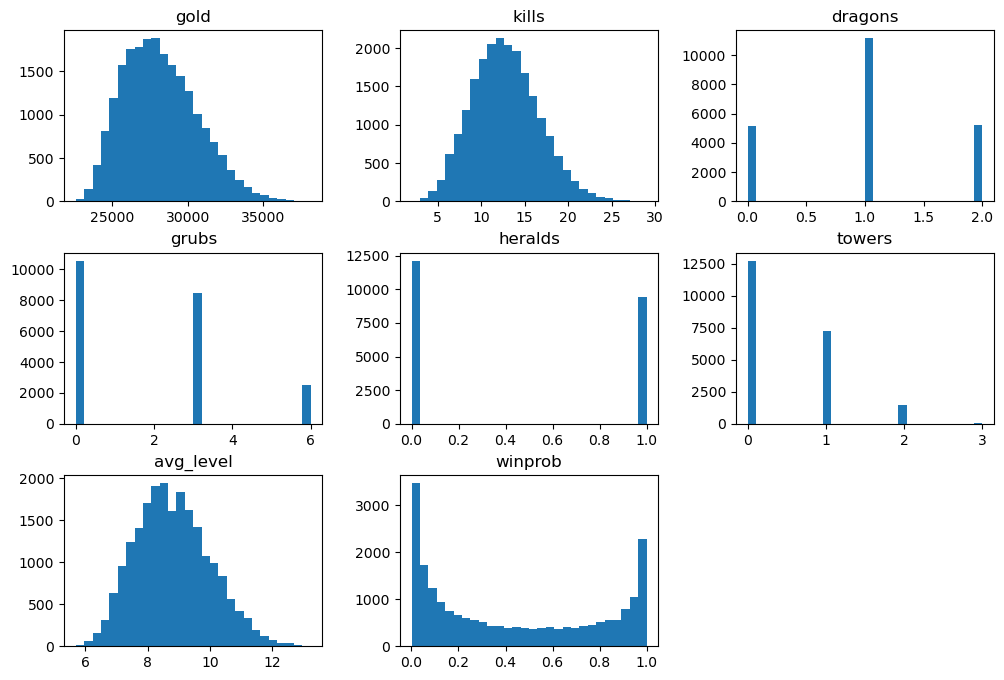

In [35]:
axes = df.hist(bins=28, figsize=(12, 8))
for ax_row in axes:
    for ax in ax_row:
        ax.grid(False)

In [34]:
df["kills"].describe()

count    21515.000000
mean        12.681106
std          3.981814
min          2.000000
25%         10.000000
50%         12.000000
75%         15.000000
max         29.000000
Name: kills, dtype: float64

In [36]:
df["avg_level"].describe()

count    21515.000000
mean         8.811672
std          1.185705
min          5.700000
25%          7.950000
50%          8.725000
75%          9.600000
max         13.225000
Name: avg_level, dtype: float64

In [37]:
df["gold"].describe()

count    21515.000000
mean     28182.170718
std       2451.134616
min      22571.000000
25%      26318.500000
50%      27945.000000
75%      29810.500000
max      38171.000000
Name: gold, dtype: float64

In [5]:
%%file lol_env.py

import random
from lol_engine import GameState, Simulator, Phase
from champion_loader import load_champion_data, load_matchups, select_champions   # <-- fix path

class LoLEnv:
    def __init__(self, model=None, seed=None):
        self.model = model
        self.seed = seed
        self.champ_df = load_champion_data("LoL_champion_data.csv")
        self.matchup_dict = load_matchups("1v1.csv")

    def reset(self, existing_state=None):
        # -- Case 1: CLI vs AI supplies an existing GameState --
        if existing_state is not None:
            self.state = existing_state
            self.sim = Simulator(self.state)
            return self._encode_state()
    
        # -- Case 2: RL training mode --
        if self.seed is not None:
            random.seed(self.seed)
    
        # load team selection utilities
        from champion_loader import load_champion_data, load_matchups, select_champions
        champ_df = load_champion_data("LoL_champion_data.csv")
        matchup_dict = load_matchups("1v1.csv")
    
        # Automatically choose champions for RL training
        self.state = select_champions(champ_df, matchup_dict, auto=True)
    
        self.sim = Simulator(self.state)
    
        return self._encode_state()


    def step(self, action):
        events, state_ref = self.sim.step_rl(action)

        next_state = self._encode_state()
        done = state_ref.phase in {Phase.T10_FINAL, Phase.DONE}

        reward = 0
        if done and self.model is not None:
            reward = self.sim.compute_final_win_probability(self.model)

        return next_state, reward, done, events

    def _encode_state(self):
        s = self.state

        return s.to_ml_vector() + [
            s.map_pressure,
            s.jungle_tempo,
            s.lane_adv_score["top"],
            s.lane_adv_score["mid"],
            s.lane_adv_score["bot"],
            float(s.phase.value),
        ]


Overwriting lol_env.py


# AI Training

In [6]:
%%file dqn_agent.py
import random
from collections import deque
from typing import List

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from lol_engine import Action


# ---------------------------------------------------------
# ACTION SPACE MAPPING
# ---------------------------------------------------------
# Fixed ordering of all possible actions. DQN always outputs
# |A| Q-values, we just mask out invalid ones each step.
ALL_ACTIONS: List[Action] = [
    Action.FARM,
    Action.GANK_TOP,
    Action.GANK_MID,
    Action.GANK_BOT,
    Action.INVADE,
    Action.CONTEST_OBJECTIVE,
    Action.GIVE_OBJECTIVE,
    Action.STEAL_ATTEMPT,
    Action.DO_NOTHING,
    Action.GO_DRAGON,
    Action.GO_GRUBS,
]

ACTION_TO_INDEX = {a: i for i, a in enumerate(ALL_ACTIONS)}
INDEX_TO_ACTION = {i: a for i, a in enumerate(ALL_ACTIONS)}


# ---------------------------------------------------------
# SIMPLE MLP Q-NETWORK
# ---------------------------------------------------------
class QNetwork(nn.Module):
    def __init__(self, state_dim: int, n_actions: int, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions),
        )

    def forward(self, x):
        return self.net(x)


# ---------------------------------------------------------
# REPLAY BUFFER
# ---------------------------------------------------------
class ReplayBuffer:
    def __init__(self, capacity: int = 50_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action_idx, reward, next_state, done):
        self.buffer.append((state, action_idx, reward, next_state, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int64),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)


# ---------------------------------------------------------
# DQN AGENT
# ---------------------------------------------------------
class DQNAgent:
    def __init__(
        self,
        state_dim: int,
        n_actions: int,
        gamma: float = 0.99,
        lr: float = 1e-3,
        batch_size: int = 64,
        target_update_freq: int = 200,
        device: str | None = None,
    ):
        self.state_dim = state_dim
        self.n_actions = n_actions
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq

        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        self.q_net = QNetwork(state_dim, n_actions).to(self.device)
        self.target_net = QNetwork(state_dim, n_actions).to(self.device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.replay_buffer = ReplayBuffer()

        self.train_steps = 0

    def select_action(self, state_vec, valid_action_indices, epsilon: float) -> int:
        """
        state_vec: 1D numpy array
        valid_action_indices: list of action indices allowed in this state
        epsilon: exploration probability
        Returns: chosen action index (int)
        """
        # ε-greedy exploration
        if random.random() < epsilon:
            return random.choice(valid_action_indices)

        # Exploitation: choose best valid action
        state_tensor = torch.tensor(state_vec, dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            q_values = self.q_net(state_tensor)[0].cpu().numpy()

        # mask invalid actions
        masked = np.full_like(q_values, -1e9, dtype=np.float32)
        masked[valid_action_indices] = q_values[valid_action_indices]

        return int(masked.argmax())

    def store_transition(self, state, action_idx, reward, next_state, done):
        self.replay_buffer.push(state, action_idx, reward, next_state, done)

    def train_step(self):
        if len(self.replay_buffer) < self.batch_size:
            return None  # not enough samples yet

        (
            states,
            actions,
            rewards,
            next_states,
            dones,
        ) = self.replay_buffer.sample(self.batch_size)

        states_t = torch.tensor(states, device=self.device)
        actions_t = torch.tensor(actions, device=self.device).unsqueeze(1)
        rewards_t = torch.tensor(rewards, device=self.device).unsqueeze(1)
        next_states_t = torch.tensor(next_states, device=self.device)
        dones_t = torch.tensor(dones, device=self.device).unsqueeze(1)

        # Q(s,a)
        q_values = self.q_net(states_t).gather(1, actions_t)

        # max_a' Q_target(s', a')
        with torch.no_grad():
            next_q_values = self.target_net(next_states_t).max(1, keepdim=True)[0]
            targets = rewards_t + (1.0 - dones_t) * self.gamma * next_q_values

        loss = nn.MSELoss()(q_values, targets)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.train_steps += 1
        if self.train_steps % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        return loss.item()


Overwriting dqn_agent.py


In [7]:
%%file train_dqn.py

import random
import numpy as np
import torch
import joblib
from tqdm.notebook import trange

from lol_engine import WinProbabilityModel
from lol_env import LoLEnv
from lol_engine import Action
from dqn_agent import (
    DQNAgent,
    ALL_ACTIONS,
    ACTION_TO_INDEX,
    INDEX_TO_ACTION,
)


def train_dqn(
    model_path="win_probability_model.joblib",
    num_episodes: int = 2000,
    max_steps_per_episode: int = 20,  # you have ~10 phases, 20 is safe
    epsilon_start: float = 1.0,
    epsilon_end: float = 0.05,
    epsilon_decay_episodes: int = 1500,
):
    sk_model = joblib.load(model_path)
    wrapped = WinProbabilityModel(sk_model)
    env = LoLEnv(model=wrapped)

    # Get state dimension from a reset
    state = env.reset()
    state_dim = len(state)
    n_actions = len(ALL_ACTIONS)

    print(f"State dim: {state_dim}, n_actions: {n_actions}")

    # -------------------------------
    # Create DQN agent
    # -------------------------------
    agent = DQNAgent(
        state_dim=state_dim,
        n_actions=n_actions,
        gamma=0.99,
        lr=1e-3,
        batch_size=64,
        target_update_freq=500,
    )

    # For reproducibility (optional)
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)

    # -------------------------------
    # Epsilon schedule
    # -------------------------------
    def get_epsilon(ep):
        if ep >= epsilon_decay_episodes:
            return epsilon_end
        ratio = ep / epsilon_decay_episodes
        return epsilon_start + ratio * (epsilon_end - epsilon_start)

    # -------------------------------
    # Training loop
    # -------------------------------
    rewards_history = []

    for episode in range(1, num_episodes + 1):
        state = env.reset()
        done = False
        total_reward = 0.0

        epsilon = get_epsilon(episode)

        for t in range(max_steps_per_episode):
            valid_actions = env.sim.get_available_actions()
            valid_indices = [ACTION_TO_INDEX[a] for a in valid_actions]

            action_idx = agent.select_action(state, valid_indices, epsilon)
            action_enum = INDEX_TO_ACTION[action_idx]

            next_state, reward, done, events = env.step(action_enum)
            total_reward += reward

            agent.store_transition(state, action_idx, reward, next_state, float(done))
            loss = agent.train_step()

            state = next_state

            if done:
                break

        rewards_history.append(total_reward)

        if episode % 50 == 0:
            avg_r = np.mean(rewards_history[-50:])
            print(f"Episode {episode}, avg_reward(last 50): {avg_r:.4f}, epsilon={epsilon:.3f}")

        
    # -------------------------------
    # Save trained DQN model
    # -------------------------------
    torch.save(agent.q_net.state_dict(), "dqn_q_network.pth")
    print("Saved DQN Q-network to dqn_q_network.pth")

    return rewards_history


if __name__ == "__main__":
    train_dqn()


Overwriting train_dqn.py


In [35]:
# train
!python train_dqn.py
print("training complete")


=== YOUR TEAM ===
    top: Kennen
 jungle: Amumu
    mid: Ekko
    bot: Smolder
support: Pantheon

=== ENEMY TEAM ===
    top: Yone
 jungle: Shyvana
    mid: Sylas
    bot: Kalista
support: Bard
State dim: 13, n_actions: 11

=== YOUR TEAM ===
    top: Dr. Mundo
 jungle: Zac
    mid: Akali
    bot: Xayah
support: Nami

=== ENEMY TEAM ===
    top: Irelia
 jungle: Karthus
    mid: Corki
    bot: Yasuo
support: Heimerdinger

=== YOUR TEAM ===
    top: Dr. Mundo
 jungle: Briar
    mid: Corki
    bot: Twitch
support: Leona

=== ENEMY TEAM ===
    top: Tahm Kench
 jungle: Rengar
    mid: Annie
    bot: Nilah
support: Senna

=== YOUR TEAM ===
    top: Darius
 jungle: Master Yi
    mid: Irelia
    bot: Jinx
support: Lux

=== ENEMY TEAM ===
    top: Poppy
 jungle: Vi
    mid: Cassiopeia
    bot: Senna
support: Lulu

=== YOUR TEAM ===
    top: Kayle
 jungle: Vi
    mid: Aurora
    bot: Ezreal
support: Morgana

=== ENEMY TEAM ===
    top: Darius
 jungle: Evelynn
    mid: Vladimir
    bot: Jhin
su

In [5]:
%%file enemy_ai.py

import torch
import numpy as np
from dqn_agent import QNetwork, ALL_ACTIONS, ACTION_TO_INDEX, INDEX_TO_ACTION

class EnemyDQN:
    def __init__(self, state_dim, model_path="dqn_q_network.pth", difficulty="medium"):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.state_dim = state_dim
        self.n_actions = len(ALL_ACTIONS)

        # Load Q-network
        self.q_net = QNetwork(state_dim, self.n_actions).to(self.device)
        self.q_net.load_state_dict(torch.load(model_path, map_location=self.device))
        self.q_net.eval()

        # Difficulty settings
        self.difficulty = difficulty
        if difficulty == "easy":
            self.epsilon = 0.50    
        elif difficulty == "medium":
            self.epsilon = 0.3
        elif difficulty == "hard":
            self.epsilon = 0.1
        elif difficulty == "master":
            self.epsilon = 0.00    # Always picks best action
        else:
            raise ValueError("Difficulty must be: easy / medium / hard / master")

    def choose_action(self, state_vec, valid_actions):
        # Convert actions to indices
        valid_indices = [ACTION_TO_INDEX[a] for a in valid_actions]

        # Epsilon = random behavior for difficulty adjustment
        if np.random.random() < self.epsilon:
            return np.random.choice(valid_actions)

        # Compute Q-values
        state_t = torch.tensor(state_vec, dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            q_vals = self.q_net(state_t)[0].cpu().numpy()

        # Mask invalid actions
        masked = np.full_like(q_vals, -1e9)
        masked[valid_indices] = q_vals[valid_indices]

        best_idx = int(np.argmax(masked))
        return INDEX_TO_ACTION[best_idx]


Overwriting enemy_ai.py


In [14]:


import random
import pandas as pd
from lol_env import LoLEnv
from enemy_ai import EnemyDQN
from champion_loader import load_champion_data, load_matchups, select_champions
from lol_engine import Simulator, Phase, WinProbabilityModel
import joblib

def auto_sim_ai(model_path="dqn_q_network.pth", n=500):
    # Load logistic regression win prob model
    sk = joblib.load("win_probability_model.joblib")
    win_model = WinProbabilityModel(sk)

    champ_df = load_champion_data("LoL_champion_data.csv")
    matchup_dict = load_matchups("1v1.csv")

    results = []

    for i in range(n):
        # Create game state
        state = select_champions(champ_df, matchup_dict, auto=True)
        sim = Simulator(state)

        # RL state encoder
        from lol_env import LoLEnv
        env = LoLEnv(model=win_model)
        state_vec = env.reset(existing_state=state)

        enemy_ai = EnemyDQN(len(state_vec), model_path=model_path, difficulty="hard")

        # MAIN GAME LOOP
        while state.phase not in {Phase.DONE, Phase.T10_FINAL}:

            # Random player action
            actions = sim.get_available_actions()
            player_action = random.choice(actions)

            # Enemy AI action
            state_vec = env._encode_state()
            enemy_actions = sim.get_available_actions()
            enemy_action = enemy_ai.choose_action(state_vec, enemy_actions)

            # Apply REAL player action logic
            events = sim.step(player_action)

            # Apply simplified enemy effect (your apply_enemy_action method)
            sim.apply_enemy_action(enemy_action)

        # Final win probability
        p = sim.compute_final_win_probability(win_model)

        results.append({
            "gold": state.blue_Total_Gold,
            "kills": state.blue_Kills,
            "dragons": state.blue_Dragons,
            "grubs": state.blue_Void_Grubs,
            "heralds": state.blue_Heralds,
            "towers": state.blue_Towers_Destroyed,
            "avg_level": state.blue_Avg_Level,
            "winprob": p,
        })

    return pd.DataFrame(results)


In [15]:
%%capture
df_ai = auto_sim_ai(model_path="dqn_q_network.pth", n=2000)


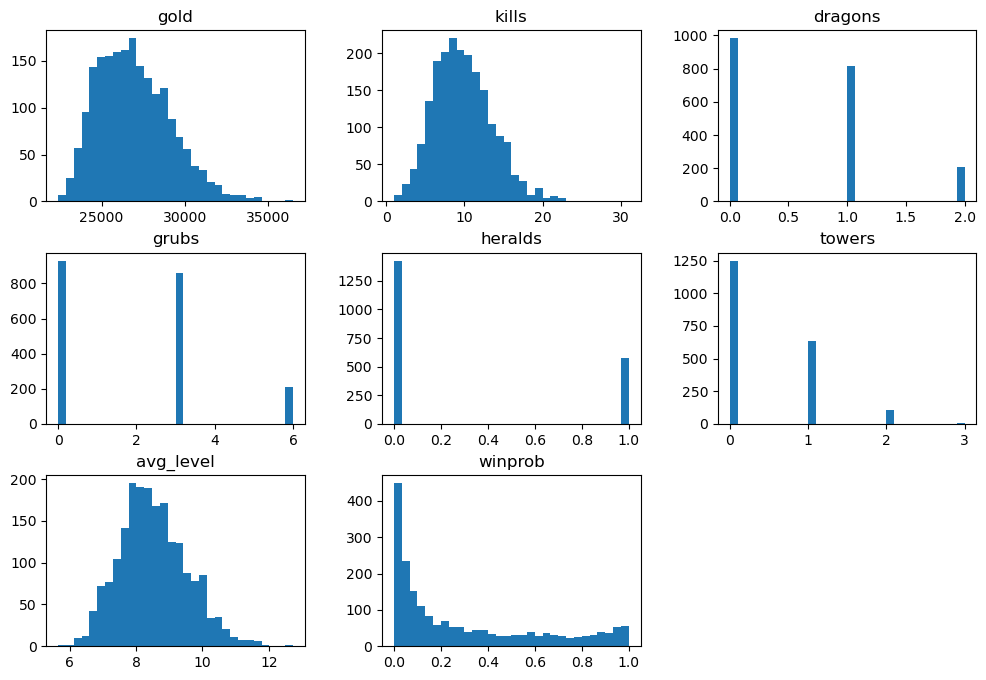

In [19]:
axes = df_ai.hist(bins=30, figsize=(12, 8))
for ax_row in axes:
    for ax in ax_row:
        ax.grid(False)

# Play

In [7]:
state, p, vote_info = run_cli_game()


Choose your jungler:
1) Amumu
2) Bel'Veth
3) Brand
4) Briar
5) Diana
6) Ekko
7) Elise
8) Evelynn
9) Fiddlesticks
10) Gragas
11) Graves
12) Hecarim
13) Ivern
14) Jarvan IV
15) Jax
16) Karthus
17) Kayn
18) Kha'Zix
19) Kindred
20) Lee Sin
21) Lillia
22) Master Yi
23) Nidalee
24) Nocturne
25) Nunu & Willump
26) Poppy
27) Rammus
28) Rek'Sai
29) Rengar
30) Sejuani
31) Shaco
32) Shyvana
33) Skarner
34) Taliyah
35) Udyr
36) Vi
37) Viego
38) Warwick
39) Wukong
40) Xin Zhao
41) Zac


Enter number:  20



=== YOUR TEAM ===
    top: Trundle
 jungle: Lee Sin
    mid: Sylas
    bot: Aphelios
support: Sona

=== ENEMY TEAM ===
    top: Mordekaiser
 jungle: Hecarim
    mid: Cassiopeia
    bot: Ziggs
support: Mel

Starting LoL jungle sim (CLI version).


--- STATE SUMMARY ---
Phase: T1_INVASION, Step: 1
Gold: 2500, Kills: 0
Drakes: 0, Grubs: 0, Heralds: 0
Towers: 0
Avg Level: 1.0
Map Pressure: 0.00, Jungle Tempo: 0.00
Lane adv (top/mid/bot): {'top': 1, 'mid': -2, 'bot': -1}

Choose action:
1) Farm jungle
2) Invade enemy jungle


Enter number:  2


Both junglers invaded opposite sides at level 1.
Both junglers invaded opposite sides. Camps traded.
Bot lane secured a kill.

--- STATE SUMMARY ---
Phase: T2_POST_CLEAR, Step: 2
Gold: 5687, Kills: 1
Drakes: 0, Grubs: 0, Heralds: 0
Towers: 0
Avg Level: 1.9
Map Pressure: 0.15, Jungle Tempo: 0.20
Lane adv (top/mid/bot): {'top': 1, 'mid': -2, 'bot': -1}

Choose action:
1) Farm jungle
2) Gank Top
3) Gank Mid
4) Gank Bot


...

Gank on bot lane FAILED. You died trying to escape.
No secondary objective remains after the dual play.
Mid lane died.
Bot lane died.

--- STATE SUMMARY ---
Phase: T9_HERALD, Step: 9
Gold: 25086, Kills: 10
Drakes: 1, Grubs: 3, Heralds: 0
Towers: 0
Avg Level: 8.7
Map Pressure: 0.70, Jungle Tempo: 0.90
Lane adv (top/mid/bot): {'top': 2, 'mid': -3, 'bot': 0}

Choose action:
1) Contest objective
2) Give objective (look for steal)


Enter number:  1


You move to CONTEST herald.
You lost the Herald fight but secured 1 kill.
Mid lane died.
Mid lane lost their tower.

--- STATE SUMMARY ---
Phase: T10_FINAL, Step: 10
Gold: 27426, Kills: 11
Drakes: 1, Grubs: 3, Heralds: 0
Towers: 0
Avg Level: 9.3
Map Pressure: 0.10, Jungle Tempo: 0.70
Lane adv (top/mid/bot): {'top': 2, 'mid': -3, 'bot': 0}


--- FINAL 15-MIN SNAPSHOT ---
Model win probability: 48.97%

Features fed into model:
  blue_Total_Gold:      27426.0
  blue_Kills:           11
  blue_Dragons:         1
  blue_Void_Grubs:      3
  blue_Heralds:         0
  blue_Towers_Destroyed:0
  blue_Avg_Level:       9.25

--- SURRENDER PHASE ---


Do you vote to surrender? (y/n):  n


Model win probability: 49.0%
Lane FF votes:
  Top: no (p≈ 0.0%)
  Mid: YES (p≈100.0%)
  Bot: no (p≈50.8%)
  Sup: no (p≈41.1%)

Final votes: 1/5 YES → SURRENDER FAILED – GAME CONTINUES.


In [6]:
# Difficulty "easy", "medium", "hard", or "master"
run_cli_vs_ai(difficulty="master")




Choose your jungler:
1) Amumu
2) Bel'Veth
3) Brand
4) Briar
5) Diana
6) Ekko
7) Elise
8) Evelynn
9) Fiddlesticks
10) Gragas
11) Graves
12) Hecarim
13) Ivern
14) Jarvan IV
15) Jax
16) Karthus
17) Kayn
18) Kha'Zix
19) Kindred
20) Lee Sin
21) Lillia
22) Master Yi
23) Nidalee
24) Nocturne
25) Nunu & Willump
26) Poppy
27) Rammus
28) Rek'Sai
29) Rengar
30) Sejuani
31) Shaco
32) Shyvana
33) Skarner
34) Taliyah
35) Udyr
36) Vi
37) Viego
38) Warwick
39) Wukong
40) Xin Zhao
41) Zac


Enter number:  20



=== YOUR TEAM ===
    top: Trundle
 jungle: Lee Sin
    mid: Veigar
    bot: Twitch
support: Braum

=== ENEMY TEAM ===
    top: Garen
 jungle: Gragas
    mid: Hwei
    bot: Zeri
support: Xerath

Starting game vs AI jungler... Difficulty: master

--- STATE SUMMARY ---
Phase: T1_INVASION, Step: 1
Gold: 2500, Kills: 0
Drakes: 0, Grubs: 0, Heralds: 0
Towers: 0
Avg Level: 1.0
Map Pressure: 0.00, Jungle Tempo: 0.00
Lane adv (top/mid/bot): {'top': 2, 'mid': 0, 'bot': 0}

Choose action:
1) Farm jungle
2) Invade enemy jungle


Enter number:  2


Enemy jungler chooses: INVADE
Both junglers invaded opposite sides at level 1.
Both junglers invaded opposite sides. Camps traded.
Top lane secured a kill.

--- STATE SUMMARY ---
Phase: T2_POST_CLEAR, Step: 2
Gold: 5507, Kills: 1
Drakes: 0, Grubs: 0, Heralds: 0
Towers: 0
Avg Level: 1.8
Map Pressure: 0.05, Jungle Tempo: 0.10
Lane adv (top/mid/bot): {'top': 2, 'mid': 0, 'bot': 0}

Choose action:
1) Farm jungle
2) Gank Top
3) Gank Mid
4) Gank Bot


...

Enemy jungler chooses: FARM
Gank on bot lane SUCCEEDED (1 kill(s)).
No secondary objective remains after the dual play.
Top lane secured a kill.

--- STATE SUMMARY ---
Phase: T9_HERALD, Step: 9
Gold: 24426, Kills: 9
Drakes: 1, Grubs: 3, Heralds: 0
Towers: 0
Avg Level: 7.3
Map Pressure: 0.45, Jungle Tempo: 0.60
Lane adv (top/mid/bot): {'top': 3, 'mid': 0, 'bot': 0}

Choose action:
1) Contest objective
2) Give objective (look for steal)


Enter number:  1


Enemy jungler chooses: CONTEST_OBJECTIVE
You move to CONTEST herald.
You lost the Herald fight but secured 1 kill.
Bot lane secured a kill.
Top lane destroyed an enemy tower.

--- STATE SUMMARY ---
Phase: T10_FINAL, Step: 10
Gold: 28488, Kills: 11
Drakes: 1, Grubs: 3, Heralds: 0
Towers: 1
Avg Level: 8.3
Map Pressure: 0.55, Jungle Tempo: 0.40
Lane adv (top/mid/bot): {'top': 3, 'mid': 0, 'bot': 1}


--- FINAL 15-MIN SNAPSHOT ---
Model win probability: 27.28%

Features fed into model:
  blue_Total_Gold:      28488.0
  blue_Kills:           11
  blue_Dragons:         1
  blue_Void_Grubs:      3
  blue_Heralds:         0
  blue_Towers_Destroyed:1
  blue_Avg_Level:       8.30

--- SURRENDER PHASE ---


Do you vote to surrender? (y/n):  y


Model win probability: 27.3%
Lane FF votes:
  Top: no (p≈ 0.0%)
  Mid: no (p≈66.4%)
  Bot: no (p≈37.3%)
  Sup: no (p≈62.5%)

Final votes: 1/5 YES → SURRENDER FAILED – GAME CONTINUES.
